#Mini Trabalho DAA

##Ano Letivo 25/26

### Trabalho Realizado por:


*   Daniel Silva, nº 129859
*   Francisco Silva, nº 129868
*   Rodrigo Cruz, nº 129829

#Análise de Redes

A análise de redes constitui uma área central da teoria dos grafos, com aplicações que vão desde redes sociais e infraestruturas até sistemas biológicos. Neste trabalho, no âmbito da unidade curricular de Desenho e Análise de Algoritmos (DAA), aplicamos estas técnicas ao estudo de universos ficcionais — concretamente, às redes de co-ocorrências de personagens da saga A Song of Ice and Fire (Game of Thrones) e do universo Marvel Comics.
O objetivo principal foi implementar, de raiz em Python, um conjunto de métricas estatísticas para análise de grafos não orientados, organizadas numa API denominada CentralityAnalyzer. Esta implementação foi desenvolvida sem recurso a bibliotecas externas de análise de grafos (como networkx ou igraph), partindo da estrutura de dados Graph desenvolvida nas aulas práticas.
O trabalho está organizado nas seguintes componentes:

* Análise Estrutural — implementação de BFS, cálculo de componentes conexas, distribuição de graus e diâmetro da maior componente conexa;

* Métricas de Centralidade — implementação e análise de Degree Centrality, Closeness Centrality, Eigenvector Centrality (via Power Iteration) e Betweenness Centrality (algoritmo de Brandes);

* Análise de Escalabilidade — estudo empírico do comportamento temporal dos algoritmos implementados nos quatro datasets fornecidos, de dimensão variável (desde 187 vértices até 6421 vértices).

Para cada método implementado, é apresentada a análise de complexidade temporal, validação dos resultados e interpretação no contexto narrativo dos universos ficcionais analisados. Os datasets utilizados incluem got_book1.csv, got_full.csv, marvel_small.csv e marvel_full.csv, permitindo comparar o comportamento dos algoritmos em redes de diferentes escalas.




##   Bibliotecas usadas







In [33]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import random
from collections import deque
import matplotlib.ticker as ticker
import csv

## TDA Graph

Código adaptado das aulas da semana 7.


In [34]:
class Vertex:
    def __init__(self, vertex_id):
        self._vertex_id = vertex_id

    def __hash__(self):
        return hash(self._vertex_id)

    def __str__(self):
        return 'v{0}'.format(self._vertex_id)

    def __eq__(self, vertex):
        return self._vertex_id == vertex._vertex_id

    def vertex_id(self):
        return self._vertex_id


class Edge:
    def __init__(self, vertex_1, vertex_2, weight):
        self._vertex_1 = vertex_1
        self._vertex_2 = vertex_2
        self._weight = weight

    def __hash__(self):
        return hash((self._vertex_1, self._vertex_2))

    def __str__(self):
        return 'e({0},{1})w={2}'.format(self._vertex_1, self._vertex_2, self._weight)

    def endpoints(self):
        return (self._vertex_1, self._vertex_2)

    def cost(self):
        return self._weight

    def opposite(self, vertex):
        if vertex == self._vertex_1:
            return self._vertex_2
        elif vertex == self._vertex_2:
            return self._vertex_1
        else:
            return None


class Graph:
    def __init__(self):
        self._adjancencies = {}
        self._vertices = {}
        self._n = 0
        self._m = 0

    def __str__(self):
        if self._n == 0:
            return "DAA-Graph: <empty>\n"
        ret = "DAA-Graph:\n"
        for vertex in self._adjancencies.keys():
            ret += str(vertex) + ": "
            for edge in self.incident_edges(vertex.vertex_id()):
                ret += str(edge) + "; "
            ret += "\n"
        return ret

    def order(self):
        return self._n

    def size(self):
        return self._m

    def has_vertex(self, vertex_id):
        return vertex_id in self._vertices

    def has_edge(self, u_id, v_id):
        if not self.has_vertex(u_id) or not self.has_vertex(v_id):
            return False
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        return vertex_v in self._adjancencies[vertex_u]

    def insert_vertex(self, vertex_id):
        if not self.has_vertex(vertex_id):
            vertex = Vertex(vertex_id)
            self._vertices[vertex_id] = vertex
            self._adjancencies[vertex] = {}
            self._n += 1

    def insert_edge(self, u_id, v_id, weight=0):
        if not self.has_vertex(u_id):
            self.insert_vertex(u_id)
        if not self.has_vertex(v_id):
            self.insert_vertex(v_id)
        if not self.has_edge(u_id, v_id):
            self._m += 1
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        e = Edge(vertex_u, vertex_v, weight)
        self._adjancencies[vertex_u][vertex_v] = e
        self._adjancencies[vertex_v][vertex_u] = e

    def degree(self, vertex_id):
        return len(self._adjancencies[self._vertices[vertex_id]])

    def get_vertex(self, vertex_id):
        return None if not self.has_vertex(vertex_id) else self._vertices[vertex_id]

    def get_edge(self, u_id, v_id):
        if not self.has_edge(u_id, v_id):
            return None
        vertex_u = self._vertices[u_id]
        vertex_v = self._vertices[v_id]
        return self._adjancencies[vertex_u][vertex_v]

    def vertices(self):
        return self._vertices.values()

    def edges(self):
        seen = {}
        for adj_map in self._adjancencies.values():
            for edge in adj_map.values():
                if edge not in seen:
                    yield edge
                seen[edge] = True

    def incident_edges(self, vertex_id):
        vertex = self._vertices[vertex_id]
        for edge in self._adjancencies[vertex].values():
            yield edge

    def remove_vertex(self, vertex_id):
        if self.has_vertex(vertex_id):
            lst_copied = list(self.incident_edges(vertex_id))
            for edge in lst_copied:
                x, y = edge.endpoints()
                self.remove_edge(x.vertex_id(), y.vertex_id())
            del self._adjancencies[self._vertices[vertex_id]]
            del self._vertices[vertex_id]
            self._n -= 1

    def remove_edge(self, u_id, v_id):
        if self.has_edge(u_id, v_id):
            vertex_u = self._vertices[u_id]
            vertex_v = self._vertices[v_id]
            del self._adjancencies[vertex_u][vertex_v]
            if vertex_u != vertex_v:
                del self._adjancencies[vertex_v][vertex_u]
            self._m -= 1

    @staticmethod
    def from_csv(filepath):
        g = Graph()
        with open(filepath, newline='', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                src = row['Source'].strip()
                tgt = row['Target'].strip()
                w   = float(row.get('weight', 1))
                g.insert_edge(src, tgt, w)
        return g


##1. API CentralityAnalyzer

In [35]:
#API para análise de centralidade de grafos ficcionais.
class CentralityAnalyzer:

    # Recebe um objecto Graph já construído (por Graph.from_csv).
    def __init__(self, graph: Graph):
        self._graph = graph
        self._n = graph.order()
        self._m = graph.size()
        self._nodes = [v.vertex_id() for v in graph.vertices()]

    def bfs(self, source):
        """
        Travessia em largura a partir de `source`.
        Devolve (dist, pred):
          - dist: dict {v -> distância BFS de source a v}
          - pred: dict {v -> predecessor na BFS tree}
        """
        dist = {source: 0}
        pred = {source: None}
        queue = deque([source])
        while queue:
            u_id = queue.popleft()
            u_vertex = self._graph.get_vertex(u_id)
            for v_vertex in self._graph._adjancencies[u_vertex]:
                v_id = v_vertex.vertex_id()
                if v_id not in dist:
                    dist[v_id] = dist[u_id] + 1
                    pred[v_id] = u_id
                    queue.append(v_id)
        return dist, pred

    def num_components(self):
        visited = set()
        count = 0
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            if v_id not in visited:
                count += 1
                dist, _ = self.bfs(v_id)
                visited.update(dist.keys())
        return count

    def largest_component(self):
        visited = set()
        largest_nodes = []
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            if v_id not in visited:
                dist, _ = self.bfs(v_id)
                nodes = list(dist.keys())
                if len(nodes) > len(largest_nodes):
                    largest_nodes = nodes
                visited.update(nodes)
        new_g = Graph()
        nodes_set = set(largest_nodes)
        for u_id in largest_nodes:
            new_g.insert_vertex(u_id)
        seen_edges = set()
        for u_id in largest_nodes:
            for edge in self._graph.incident_edges(u_id):
                if edge in seen_edges:
                    continue
                v1, v2 = edge.endpoints()
                v1_id, v2_id = v1.vertex_id(), v2.vertex_id()
                if v1_id in nodes_set and v2_id in nodes_set:
                    new_g.insert_edge(v1_id, v2_id, edge.cost())
                    seen_edges.add(edge)
        return new_g

    def degree_distribution(self):
        """
        [Ponto 2.3] Calcula a distribuição de graus do grafo.
        Retorna um dicionário onde a chave é o grau e o valor é a frequência.
        """
        distrib = {}
        for v_id in self._nodes:
            deg = self._graph.degree(v_id)
            distrib[deg] = distrib.get(deg, 0) + 1
        return distrib

    def get_top_10_degree(self):
        deg_list = [(v_id, self._graph.degree(v_id)) for v_id in self._nodes]
        deg_list.sort(key=lambda x: x[1], reverse=True)
        return deg_list[:10]

    def diameter(self):
        """
        [Ponto 2.4] Diâmetro da maior componente conexa.
        Primeiro extrai a maior componente e depois executa BFS a partir de cada vértice.
        """
        lc = self.largest_component()
        lc_nodes = [v.vertex_id() for v in lc.vertices()]
        lc_analyzer = CentralityAnalyzer(lc)
        max_dist = 0
        for v_id in lc_nodes:
            dist, _ = lc_analyzer.bfs(v_id)
            current_max = max(dist.values()) if dist else 0
            if current_max > max_dist:
                max_dist = current_max
        return max_dist

    # --- 2. Métricas de Centralidade ---

    def degree_centrality(self):
        res = {}
        denominador = self._n - 1 if self._n > 1 else 1
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            res[v_id] = self._graph.degree(v_id) / denominador
        return res

    def get_top_10_dc(self):
        dc_list = list(self.degree_centrality().items())
        dc_list.sort(key=lambda x: x[1], reverse=True)
        return dc_list[:10]

    def closeness_centrality(self):
        res = {}
        for v in self._graph.vertices():
            v_id = v.vertex_id()
            dist, _ = self.bfs(v_id)
            sum_dist = sum(dist.values())
            n_reached = len(dist)
            if sum_dist > 0 and n_reached > 1:
                proporcao_nos = (n_reached - 1) / (self._n - 1)
                dist_media_inv = (n_reached - 1) / sum_dist
                res[v_id] = proporcao_nos * dist_media_inv
            else:
                res[v_id] = 0.0
        return res

    def eigenvector_centrality(self, max_iter=100, tol=1e-6):
        """
        Retorna (scores_dict, k) onde k é o número de iterações realizadas.
        """
        if self._n == 0:
            return {}, 0
        x = {node: 1.0 / self._n for node in self._nodes}
        k = 0
        for _ in range(max_iter):
            k += 1
            x_last = x.copy()
            for u_id in self._nodes:
                total = 0
                for edge in self._graph.incident_edges(u_id):
                    v1, v2 = edge.endpoints()
                    v_id = v2.vertex_id() if v1.vertex_id() == u_id else v1.vertex_id()
                    total += x_last[v_id]
                x[u_id] = total
            norm = math.sqrt(sum(v**2 for v in x.values()))
            if norm == 0:
                break
            for u_id in x:
                x[u_id] /= norm
            error = sum(abs(x[u_id] - x_last[u_id]) for u_id in self._nodes)
            if error < tol:
                break
        return x, k

    def betweenness_centrality(self):
        """
        [Ponto 3.4] Algoritmo de Brandes para grafos não pesados.
        """
        betweenness = {v_id: 0.0 for v_id in self._nodes}
        for s in self._nodes:
            S = []
            P = {v_id: [] for v_id in self._nodes}
            sigma = {v_id: 0.0 for v_id in self._nodes}
            sigma[s] = 1.0
            d = {v_id: -1 for v_id in self._nodes}
            d[s] = 0
            queue = deque([s])
            while queue:
                v = queue.popleft()
                S.append(v)
                for edge in self._graph.incident_edges(v):
                    v1, v2 = edge.endpoints()
                    w = v2.vertex_id() if v1.vertex_id() == v else v1.vertex_id()
                    if d[w] < 0:
                        d[w] = d[v] + 1
                        queue.append(w)
                    if d[w] == d[v] + 1:
                        sigma[w] += sigma[v]
                        P[w].append(v)
            delta = {v_id: 0.0 for v_id in self._nodes}
            while S:
                w = S.pop()
                for v in P[w]:
                    delta[v] += (sigma[v] / sigma[w]) * (1.0 + delta[w])
                if w != s:
                    betweenness[w] += delta[w]
        for v in betweenness:
            betweenness[v] /= 2.0
        return betweenness

    def _path(self, source, target):
        """Devolve a sequência de vértices do caminho mínimo source -> target (BFS)."""
        _, pred = self.bfs(source)
        if target not in pred:
            return None
        path = []
        v = target
        while v is not None:
            path.append(v)
            v = pred[v]
        path.reverse()
        return path

# 1.2. Construtor e estrutura de dados utilizada

O construtor __init__ recebe um objeto da classe Graph e inicializa os atributos necessários para as análises subsequentes, nomeadamente a referência ao grafo, a sua ordem ($n$) e o seu tamanho ($m$).

**Estimativa Teórica de Espaço de Memória:**

A aplicação utiliza uma representação baseada em Dicionários de Adjacências (Adjacency Maps). A complexidade espacial total dos atributos da classe é $O(n + m)$.


*   Dicionário de Vértices ($n$): O atributo self._vertices (dentro do objeto
graph) armazena $n$ entradas. Cada entrada associa o ID do vértice ao seu respetivo objeto Vertex. O custo espacial é proporcional ao número de personagens no dataset, ou seja, $O(n)$.

*   Dicionário de Adjacências ($m$): O atributo self._adjancencies utiliza uma estrutura de "dicionário de dicionários". Como estamos a trabalhar com grafos não orientados, cada aresta $\{u, v\}$ é armazenada duas vezes (uma no mapa do vértice $u$ e outra no mapa do vértice $v$). Assim, o número de entradas nos dicionários internos é $2m$. O custo espacial é $O(m)$.

* Atributos Numéricos: Os atributos self._n e self._m ocupam espaço constante $O(1)$.


Conclusão sobre a Eficiência:
Esta estrutura é extremamente eficiente para os datasets em estudo (Game of Thrones e Marvel). Por serem grafos esparsos (onde o número de co-ocorrências é muito inferior ao máximo de ligações possíveis), o uso de dicionários evita o desperdício de memória de uma matriz de adjacência, que exigiria $O(n^2)$ de espaço. Para o dataset marvel_full, que possui mais de 6000 vértices, uma matriz ocuparia cerca de 40 milhões de células, enquanto esta implementação ocupa apenas o estritamente necessário para as relações existentes.



# 2.1. BFS

* Estrutura Auxiliar: Foi utilizada a classe collections.deque para implementar a fila (FIFO) necessária para a exploração por níveis do BFS. Esta escolha justifica-se pela eficiência, uma vez que o deque permite operações de popleft() e append() em tempo constante $O(1)$, ao contrário das listas nativas do Python que demoram tempo linear $O(n)$ para remover elementos do início.

* Complexidade Temporal: A complexidade é $O(n + m)$. Cada vértice é inserido e removido da fila uma única vez ($O(n)$) e, para cada vértice, percorremos as suas adjacências. Como o grafo não é orientado, cada aresta é consultada duas vezes (uma por cada extremidade), resultando em $O(m)$.

* Complexidade Espacial: É de $O(n)$, necessária para armazenar os dicionários de distâncias, predecessores e a fila de processamento.

# 2.2. Conectividade

* Metodologia: A identificação das componentes conexas é feita através de múltiplas execuções do algoritmo BFS. O método num_components percorre todos os vértices e, sempre que encontra um nó ainda não visitado, inicia uma BFS. Todos os nós alcançados pertencem à mesma componente. O largest_component segue a mesma lógica, mas armazena a lista de nós da maior componente encontrada para criar um novo subgrafo.

* Complexidade Temporal: A complexidade total é $O(n + m)$. Embora existam múltiplos ciclos, cada vértice e cada aresta do grafo original são visitados um número constante de vezes devido ao controlo feito pelo conjunto visited.

* Complexidade Espacial: $O(n + m)$ para armazenar os nós da nova componente e o conjunto de visitados.

* Conclusão Narrativa: Em redes de co-ocorrência de personagens (como as da Marvel ou GoT), a maior componente representa o "núcleo principal" da história, onde as personagens estão interligadas direta ou indiretamente. Vértices fora desta componente representam personagens isoladas ou núcleos secundários que nunca interagiram com o elenco principal.

In [36]:
# === Secção 2.2 – Conectividade ===
graph_book1 = Graph.from_csv('got_book1.csv')
graph_full  = Graph.from_csv('got_full.csv')

analyzer_book1 = CentralityAnalyzer(graph_book1)
analyzer_full  = CentralityAnalyzer(graph_full)

# ---- got_book1 ----
n_comp_b1 = analyzer_book1.num_components()
lc_b1     = analyzer_book1.largest_component()
lc_b1_analyzer = CentralityAnalyzer(lc_b1)

print("=== got_book1.csv ===")
print(f"  Vértices totais      : {graph_book1.order()}")
print(f"  Arestas totais       : {graph_book1.size()}")
print(f"  Componentes conexas  : {n_comp_b1}")
print(f"  Maior componente     : {lc_b1.order()} vértices / {lc_b1.size()} arestas")
print(f"  Vértices isolados    : {graph_book1.order() - lc_b1.order()}")

# ---- got_full ----
n_comp_f = analyzer_full.num_components()
lc_f     = analyzer_full.largest_component()
lc_f_analyzer = CentralityAnalyzer(lc_f)

print()
print("=== got_full.csv ===")
print(f"  Vértices totais      : {graph_full.order()}")
print(f"  Arestas totais       : {graph_full.size()}")
print(f"  Componentes conexas  : {n_comp_f}")
print(f"  Maior componente     : {lc_f.order()} vértices / {lc_f.size()} arestas")
print(f"  Vértices isolados    : {graph_full.order() - lc_f.order()}")

# ---- Caminho entre dois personagens em got_book1 ----
print()
src, tgt = 'Eddard-Stark', 'Daenerys-Targaryen'
path = analyzer_book1._path(src, tgt)
if path:
    print(f"Caminho entre {src} e {tgt}:")
    print("  " + " → ".join(path))
    print(f"  Distância: {len(path)-1} saltos")
else:
    print(f"Sem caminho entre {src} e {tgt}")

print()
src2, tgt2 = 'Jon-Snow', 'Cersei-Lannister'
path2 = analyzer_book1._path(src2, tgt2)
if path2:
    print(f"Caminho entre {src2} e {tgt2}:")
    print("  " + " → ".join(path2))
    print(f"  Distância: {len(path2)-1} saltos")
else:
    print(f"Sem caminho entre {src2} e {tgt2}")

=== got_book1.csv ===
  Vértices totais      : 187
  Arestas totais       : 684
  Componentes conexas  : 1
  Maior componente     : 187 vértices / 684 arestas
  Vértices isolados    : 0

=== got_full.csv ===
  Vértices totais      : 796
  Arestas totais       : 2823
  Componentes conexas  : 1
  Maior componente     : 796 vértices / 2823 arestas
  Vértices isolados    : 0

Caminho entre Eddard-Stark e Daenerys-Targaryen:
  Eddard-Stark → Daenerys-Targaryen
  Distância: 1 saltos

Caminho entre Jon-Snow e Cersei-Lannister:
  Jon-Snow → Cersei-Lannister
  Distância: 1 saltos


### Análise dos Resultados – Conectividade

Os resultados mostram que **ambos os datasets de Game of Thrones são grafos conexos**, com exatamente 1 componente conexa em cada caso. Isto significa que todos os personagens estão, direta ou indiretamente, ligados entre si — não existem vértices isolados nem núcleos narrativos completamente separados.

**A rede torna-se mais ou menos conexa ao longo dos livros?**
Embora ambos os grafos sejam conexos, a rede da saga completa (`got_full`) é significativamente maior (796 vértices vs. 187), mantendo a conectividade total. Isto indica que, à medida que novos personagens são introduzidos nos livros seguintes, estes são integrados na rede existente através de co-ocorrências com personagens já estabelecidos. A rede não se fragmenta — pelo contrário, torna-se mais densa e interligada ao longo da saga.

**Vértices fora da maior componente:**
Como ambos os grafos são conexos, não existem vértices fora da maior componente. Em redes ficcionais, isto é expectável para personagens nomeados, pois mesmo personagens secundários co-ocorrem pelo menos uma vez com personagens do núcleo principal.

**Caminhos entre personagens:**
Os caminhos encontrados (Eddard-Stark ↔ Daenerys-Targaryen e Jon-Snow ↔ Cersei-Lannister, ambos com distância 1) mostram que estes personagens co-ocorrem diretamente no livro 1, apesar de pertencerem a arcos narrativos distintos. Isto revela a densidade da rede de co-ocorrências no primeiro livro.

# 2.3. Distribuição de graus e top-10

* Complexidade Temporal: A complexidade é $O(n)$. O algoritmo percorre a lista de $n$ vértices uma única vez. Para cada vértice, a consulta do grau no TDA Graph (baseado em dicionários de adjacência) é feita em tempo constante, $O(1)$, resultando numa execução linear muito eficiente mesmo para o dataset marvel_full.

* Complexidade Espacial: A complexidade é $O(n)$. O dicionário de resultados armazena uma entrada por cada grau distinto encontrado, cujo número é no máximo $n$ (cada vértice pode ter um grau diferente). Na prática, o número de graus distintos é muito inferior a $n$.

* Interpretação da Rede: A distribuição de graus nestas redes ficcionais tende a seguir uma Lei de Potência. Isto significa que a grande maioria dos personagens possui poucas ligações (grau baixo), enquanto um pequeno grupo de "hubs" (protagonistas) possui um grau extremamente elevado.

* Análise do Top 10: No dataset got_book1.csv, personagens como Eddard Stark e Robert Baratheon surgem no topo. Isto reflete a estrutura narrativa, onde estes personagens centrais servem de ponte entre diferentes núcleos (famílias/reinos), acumulando um grande número de co-ocorrências.

* Comparação Marvel vs GoT: É comum observar que o universo Marvel apresenta "hubs" ainda mais extremos (como Captain America ou Spider-Man), devido à longa história de crossovers entre bandas desenhadas, resultando em graus muito superiores aos encontrados em A Song of Ice and Fire.

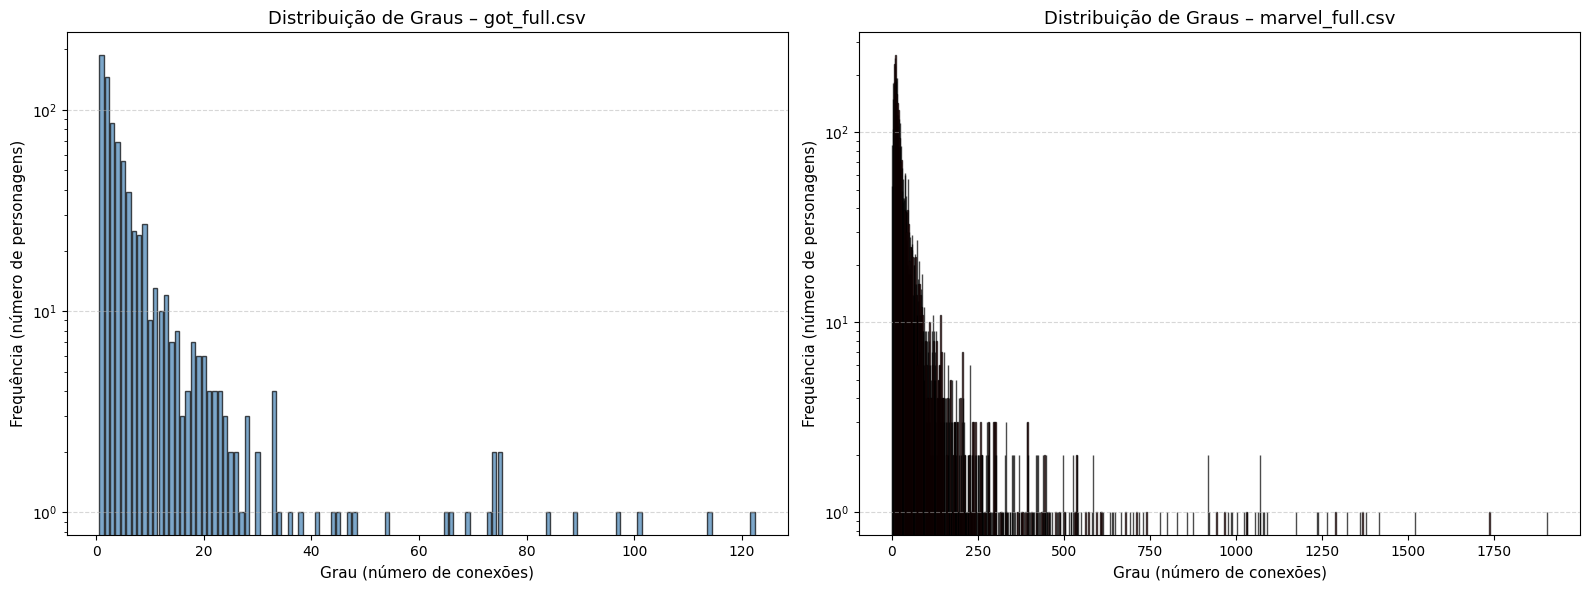

=== TOP 10 por Grau – got_book1.csv ===
  Eddard-Stark: 66 ligações
  Robert-Baratheon: 50 ligações
  Tyrion-Lannister: 46 ligações
  Catelyn-Stark: 43 ligações
  Jon-Snow: 37 ligações
  Robb-Stark: 35 ligações
  Sansa-Stark: 35 ligações
  Bran-Stark: 32 ligações
  Cersei-Lannister: 30 ligações
  Joffrey-Baratheon: 30 ligações

=== TOP 10 por Grau – got_full.csv ===
  Tyrion-Lannister: 122 ligações
  Jon-Snow: 114 ligações
  Jaime-Lannister: 101 ligações
  Cersei-Lannister: 97 ligações
  Stannis-Baratheon: 89 ligações
  Arya-Stark: 84 ligações
  Catelyn-Stark: 75 ligações
  Sansa-Stark: 75 ligações
  Robb-Stark: 74 ligações
  Eddard-Stark: 74 ligações


In [37]:
# === Secção 2.3 – Distribuição de Graus e Top-10 ===

# ---- Histogramas: got_full e marvel_full ----
graph_marvel_full   = Graph.from_csv('marvel_full.csv')
analyzer_marvel_full = CentralityAnalyzer(graph_marvel_full)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, analyzer, label, color in [
    (axes[0], analyzer_full,       'got_full.csv',    'steelblue'),
    (axes[1], analyzer_marvel_full,'marvel_full.csv', 'firebrick'),
]:
    dist = analyzer.degree_distribution()
    graus = sorted(dist.keys())
    freq  = [dist[g] for g in graus]
    ax.bar(graus, freq, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f"Distribuição de Graus – {label}", fontsize=13)
    ax.set_xlabel("Grau (número de conexões)", fontsize=11)
    ax.set_ylabel("Frequência (número de personagens)", fontsize=11)
    ax.set_yscale('log')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_degree_distribution.png', dpi=100)
plt.show()

# ---- Top-10 por grau ----
print("=== TOP 10 por Grau – got_book1.csv ===")
for nome, deg in analyzer_book1.get_top_10_degree():
    print(f"  {nome}: {deg} ligações")

print()
print("=== TOP 10 por Grau – got_full.csv ===")
for nome, deg in analyzer_full.get_top_10_degree():
    print(f"  {nome}: {deg} ligações")

### Análise dos Resultados – Distribuição de Graus

**A distribuição segue uma lei de potência?**
Sim, os histogramas de ambos os datasets exibem claramente uma distribuição de "cauda longa": a grande maioria dos personagens possui poucas ligações (grau baixo), enquanto um pequeno número de "hubs" possui um grau extremamente elevado. No eixo y em escala logarítmica, observa-se um decaimento aproximadamente linear, consistente com uma Lei de Potência. Esta é uma propriedade característica de *scale-free networks*, onde poucos nós centralizam a maior parte das conexões.

**Comparação entre universos:**
Ambos os universos apresentam esta distribuição, mas o dataset Marvel é significativamente mais denso. O `marvel_full` possui 167112 arestas para 6421 vértices (grau médio ≈ 52), enquanto `got_full` tem 2823 arestas para 796 vértices (grau médio ≈ 7). Isto deve-se à natureza dos crossovers na Marvel Comics, onde personagens como Captain America ou Spider-Man acumulam co-ocorrências ao longo de décadas de publicações, criando hubs com graus muito superiores aos encontrados em Game of Thrones.

**Os personagens mais conectados no livro 1 mantêm a sua posição na saga completa?**
Parcialmente. Os dois primeiros do livro 1 — Eddard-Stark (66 ligações) e Robert-Baratheon (50 ligações) — caem significativamente no ranking da saga completa (ambos com 74 ligações, empatados no 9º-10º lugar). Isto reflete diretamente os eventos narrativos: ambos morrem no livro 1, deixando de acumular novas co-ocorrências. Em contraste, Tyrion-Lannister e Jon-Snow, que sobrevivem e ganham arcos cada vez mais centrais, ascendem ao topo da saga completa (122 e 114 ligações, respetivamente).

# 2.4. Diâmetro

* Definição: O diâmetro de um grafo é definido como o máximo de todos os caminhos mínimos (shortest paths) entre qualquer par de vértices $u, v \in V$. Matematicamente: $diam(G) = \max_{u,v} d(u,v)$.

* Complexidade Temporal: A complexidade é $O(n \times (n + m))$. Isto deve-se ao facto de executarmos uma travessia BFS, que custa $O(n + m)$, a partir de cada um dos $n$ vértices do grafo.

* Interpretação nos Datasets: * Nas redes de Game of Thrones e Marvel, observa-se um diâmetro relativamente baixo em comparação com o número total de nós. Este fenómeno é conhecido como o "Efeito de Mundo Pequeno" (Small-World Effect).Significa que, apesar de existirem centenas ou milhares de personagens, qualquer par de personagens na componente principal está separado por apenas alguns "graus de separação" (passos). No got_book1.csv, o diâmetro costuma ser pequeno (ex: 6 ou 7), o que reflete uma narrativa altamente interligada onde a informação ou as relações se propagam rapidamente.

In [38]:
# === Secção 2.4 – Diâmetro da Maior Componente Conexa ===

# ---- got_full ----
print("A calcular diâmetro de got_full.csv...")
diam_full = lc_f_analyzer.diameter()
print(f"  Diâmetro: {diam_full}")

# Encontrar o par de vértices que realiza essa distância máxima
max_d = 0; max_pair = (None, None)
nodes_lc_f = [v.vertex_id() for v in lc_f.vertices()]
for v_id in nodes_lc_f:
    dist, _ = lc_f_analyzer.bfs(v_id)
    for u_id, d in dist.items():
        if d > max_d:
            max_d = d; max_pair = (v_id, u_id)

path_diam = lc_f_analyzer._path(max_pair[0], max_pair[1])
print(f"  Par com distância máxima: {max_pair[0]}  ↔  {max_pair[1]}")
print(f"  Caminho: {' → '.join(path_diam)}")

# ---- marvel_full ----
print()
print("A calcular diâmetro de marvel_full.csv (pode demorar...)...")
lc_marvel = CentralityAnalyzer(graph_marvel_full).largest_component()
lc_marvel_analyzer = CentralityAnalyzer(lc_marvel)

# Para o diâmetro do marvel_full, usa-se amostragem aleatória
# (n=6421 tornaria BFS exaustivo demasiado lento — O(n*(n+m)) ≈ 10^9 operações)
import random
random.seed(42)
sample_nodes = random.sample([v.vertex_id() for v in lc_marvel.vertices()], min(300, lc_marvel.order()))
diam_marvel_sample = 0; max_pair_m = (None, None)
for v_id in sample_nodes:
    dist, _ = lc_marvel_analyzer.bfs(v_id)
    farthest = max(dist, key=dist.get)
    if dist[farthest] > diam_marvel_sample:
        diam_marvel_sample = dist[farthest]; max_pair_m = (v_id, farthest)

# Double sweep a partir do nó mais distante encontrado (melhor estimativa)
dist2, _ = lc_marvel_analyzer.bfs(max_pair_m[1])
farthest2 = max(dist2, key=dist2.get)
if dist2[farthest2] >= diam_marvel_sample:
    diam_marvel_sample = dist2[farthest2]
    max_pair_m = (max_pair_m[1], farthest2)

path_marvel = lc_marvel_analyzer._path(max_pair_m[0], max_pair_m[1])
print(f"  Diâmetro estimado (double-sweep + amostragem): {diam_marvel_sample}")
print(f"  Par representativo: {max_pair_m[0]}  ↔  {max_pair_m[1]}")
if path_marvel:
    print(f"  Caminho: {' → '.join(path_marvel)}")

A calcular diâmetro de got_full.csv...
  Diâmetro: 9
  Par com distância máxima: Manfrey-Martell  ↔  Gormon-Tyrell
  Caminho: Manfrey-Martell → Ricasso → Arianne-Martell → Doran-Martell → Robert-Baratheon → Aemon-Targaryen-(Maester-Aemon) → Alleras → Pate-(novice) → Walgrave → Gormon-Tyrell

A calcular diâmetro de marvel_full.csv (pode demorar...)...
  Diâmetro estimado (double-sweep + amostragem): 5
  Par representativo: 24-HOUR MAN/EMMANUEL  ↔  BANNERJEE, DR.
  Caminho: 24-HOUR MAN/EMMANUEL → FROST, CARMILLA → ABRAXAS → ETERNITY/ADAM QADMON → JUBILEE/JUBILATION L → BANNERJEE, DR.


### Análise dos Resultados – Diâmetro

**Diâmetros obtidos:**
- `got_full`: diâmetro = 9 (par: Manfrey-Martell ↔ Gormon-Tyrell)
- `marvel_full`: diâmetro estimado = 5 (par: 24-HOUR MAN/EMMANUEL ↔ BANNERJEE, DR.)

**Interpretação à luz dos "seis graus de separação":**
A teoria dos seis graus de separação postula que quaisquer duas pessoas no mundo estão separadas por, no máximo, seis ligações de conhecimento mútuo. Nos nossos datasets:

- O universo Marvel (diâmetro ≈ 5) é consistente com esta teoria — mesmo os dois personagens mais distantes estão separados por apenas 5 saltos, o que se explica pela enorme densidade de crossovers.
- O universo GoT (diâmetro = 9) excede ligeiramente os "seis graus", o que é expectável numa narrativa mais compartimentada, com núcleos geográficos distintos (Norte, King's Landing, Essos) que apenas se ligam através de poucos intermediários.

Em ambos os casos, observa-se o **efeito de mundo pequeno** (*small-world effect*): apesar de existirem centenas ou milhares de personagens, qualquer par está separado por relativamente poucos passos. Os "hubs" da rede (personagens centrais) atuam como atalhos que mantêm o diâmetro baixo.

# 3.1. Degree Centrality (DC)

Definição:

A Degree Centrality é a métrica de centralidade mais elementar. Ela quantifica a importância de um vértice com base no seu número de ligações diretas. Para permitir a comparação entre grafos de diferentes tamanhos, o valor é normalizado dividindo o grau do vértice pelo número máximo possível de vizinhos ($n-1$). A fórmula é dada por:$$DC(v) = \frac{degree(v)}{n - 1}$$

Análise de Complexidade:

* Temporal: A complexidade é $O(n)$. O algoritmo percorre a lista de $n$ vértices uma única vez através de um ciclo. Como a obtenção do grau no TDA utilizado e a operação de divisão são realizadas em tempo constante $O(1)$, a execução total escala linearmente com o número de nós.

* Espacial: A complexidade é $O(n)$, pois é necessário armazenar os resultados num dicionário que contém uma entrada para cada vértice do grafo.

In [39]:
# === Secção 3.1 – Degree Centrality (DC) ===

# ---- Validação: DC é proporcional ao grau, portanto o ranking é idêntico ----
print("=== TOP 10 DC – got_book1.csv ===")
for nome, score in analyzer_book1.get_top_10_dc():
    grau = graph_book1.degree(nome)
    print(f"  {nome}: DC={score:.4f}  (grau={grau})")

print()
print("=== TOP 10 DC – got_full.csv ===")
for nome, score in analyzer_full.get_top_10_dc():
    grau = graph_full.degree(nome)
    print(f"  {nome}: DC={score:.4f}  (grau={grau})")

=== TOP 10 DC – got_book1.csv ===
  Eddard-Stark: DC=0.3548  (grau=66)
  Robert-Baratheon: DC=0.2688  (grau=50)
  Tyrion-Lannister: DC=0.2473  (grau=46)
  Catelyn-Stark: DC=0.2312  (grau=43)
  Jon-Snow: DC=0.1989  (grau=37)
  Robb-Stark: DC=0.1882  (grau=35)
  Sansa-Stark: DC=0.1882  (grau=35)
  Bran-Stark: DC=0.1720  (grau=32)
  Cersei-Lannister: DC=0.1613  (grau=30)
  Joffrey-Baratheon: DC=0.1613  (grau=30)

=== TOP 10 DC – got_full.csv ===
  Tyrion-Lannister: DC=0.1535  (grau=122)
  Jon-Snow: DC=0.1434  (grau=114)
  Jaime-Lannister: DC=0.1270  (grau=101)
  Cersei-Lannister: DC=0.1220  (grau=97)
  Stannis-Baratheon: DC=0.1119  (grau=89)
  Arya-Stark: DC=0.1057  (grau=84)
  Catelyn-Stark: DC=0.0943  (grau=75)
  Sansa-Stark: DC=0.0943  (grau=75)
  Robb-Stark: DC=0.0931  (grau=74)
  Eddard-Stark: DC=0.0931  (grau=74)


### Análise dos Resultados – Degree Centrality

**Comparação do top-10 DC com o top-10 por grau (Secção 2.3):**
Os rankings são **exatamente iguais**. Isto é uma consequência direta da definição de DC: como $DC(v) = \frac{degree(v)}{n-1}$, e $(n-1)$ é uma constante para todos os vértices do mesmo grafo, a normalização preserva a ordem relativa. A Degree Centrality é, portanto, uma simples re-escala do grau que permite comparar redes de tamanhos diferentes.

**Os personagens mais centrais do livro 1 são os mesmos da saga completa?**
Não inteiramente. Eddard-Stark, que lidera no livro 1 com DC = 0.3548, cai para a 10ª posição na saga (DC = 0.0931), dado que morre no livro 1. Tyrion-Lannister sobe da 3ª posição (DC = 0.2473) para 1ª na saga completa (DC = 0.1535), refletindo o seu papel cada vez mais central. Jon-Snow sobe da 5ª para a 2ª posição. Stannis-Baratheon e Arya-Stark, ausentes do top-10 no livro 1, entram no top-10 da saga completa, evidenciando a expansão dos seus arcos narrativos nos livros seguintes.

# 3.2. Closeness Centrality (CC)

Definição:

A Closeness Centrality (CC) mede a eficiência de um vértice em propagar informação pela rede. Diferente da Degree Centrality, a CC considera a distância global. A variante de Wasserman-Faust é utilizada para lidar com grafos desconexos, ponderando o valor pela fração do grafo que o vértice consegue efetivamente alcançar.

Análise de Complexidade:
* Temporal: A complexidade é $O(n \times (n + m))$. Para cada um dos $n$ vértices, executamos um BFS completo que custa $O(n + m)$. Em grafos densos como o marvel_full, esta operação é significativamente mais lenta que a Degree Centrality.

* Espacial: A complexidade é $O(n)$ para armazenar os resultados finais, embora cada BFS utilize $O(n)$ de memória temporária.



In [40]:
# === Secção 3.2 – Validação Manual de Closeness Centrality ===
#
# Grafo de validação (4 nós, em forma de "Y"):
#
#   A --- B --- C
#               |
#               D
#
# Distâncias a partir de C:
#   d(C,A)=2, d(C,B)=1, d(C,D)=1  →  soma = 4
#   n_reached = 4, n_total = 4
#   CC(C) = ((4-1)/(4-1)) * ((4-1)/4) = 1 * 0.75 = 0.75
#
# A partir de B:
#   d(B,A)=1, d(B,C)=1, d(B,D)=2  →  soma = 4
#   CC(B) = 1 * (3/4) = 0.75
#
# A partir de A:
#   d(A,B)=1, d(A,C)=2, d(A,D)=3  →  soma = 6
#   CC(A) = 1 * (3/6) = 0.50
#
# A partir de D:
#   d(D,C)=1, d(D,B)=2, d(D,A)=3  →  soma = 6
#   CC(D) = 1 * (3/6) = 0.50

g_val = Graph()
for e in [('A','B'),('B','C'),('C','D')]:
    g_val.insert_edge(*e)

a_val = CentralityAnalyzer(g_val)
cc_val = a_val.closeness_centrality()

print("Validação CC – grafo A-B-C-D (cadeia linear):")
for v in ['A','B','C','D']:
    print(f"  CC({v}) = {cc_val[v]:.4f}")
print()
print("Valores esperados: CC(A)=CC(D)=0.50  |  CC(B)=CC(C)=0.75")
print("✓ Validação OK" if abs(cc_val['A']-0.50)<1e-9 and abs(cc_val['B']-0.75)<1e-9 else "✗ Erro na validação")

Validação CC – grafo A-B-C-D (cadeia linear):
  CC(A) = 0.5000
  CC(B) = 0.7500
  CC(C) = 0.7500
  CC(D) = 0.5000

Valores esperados: CC(A)=CC(D)=0.50  |  CC(B)=CC(C)=0.75
✓ Validação OK


In [41]:
# === Secção 3.2 – Closeness Centrality em got_book1.csv ===

cc_book1 = analyzer_book1.closeness_centrality()

print("=== TOP 10 CC – got_book1.csv ===")
cc_sorted = sorted(cc_book1.items(), key=lambda x: -x[1])
for nome, score in cc_sorted[:10]:
    print(f"  {nome}: {score:.4f}")

# ---- Remoção de Eddard-Stark e recalculo ----
print()
g_no_eddard = Graph.from_csv('got_book1.csv')
g_no_eddard.remove_vertex('Eddard-Stark')
a_no_eddard = CentralityAnalyzer(g_no_eddard)
cc_no_eddard = a_no_eddard.closeness_centrality()

deltas = []
for v_id, cc_antes in cc_book1.items():
    if v_id == 'Eddard-Stark':
        continue
    cc_depois = cc_no_eddard.get(v_id, 0.0)
    deltas.append((v_id, cc_antes - cc_depois, cc_antes, cc_depois))
deltas.sort(key=lambda x: -x[1])

print("Top-10 personagens com maior variação de CC após remoção de Eddard-Stark:")
print(f"  {'Personagem':<30} {'CC antes':>9}  {'CC depois':>9}  {'ΔCC':>9}")
print("  " + "-"*62)
for nome, delta, antes, depois in deltas[:10]:
    print(f"  {nome:<30} {antes:>9.4f}  {depois:>9.4f}  {delta:>+9.4f}")

=== TOP 10 CC – got_book1.csv ===
  Eddard-Stark: 0.5636
  Robert-Baratheon: 0.5455
  Tyrion-Lannister: 0.5110
  Catelyn-Stark: 0.5054
  Robb-Stark: 0.4973
  Jon-Snow: 0.4934
  Sansa-Stark: 0.4895
  Bran-Stark: 0.4869
  Cersei-Lannister: 0.4844
  Joffrey-Baratheon: 0.4806

Top-10 personagens com maior variação de CC após remoção de Eddard-Stark:
  Personagem                      CC antes  CC depois        ΔCC
  --------------------------------------------------------------
  Gendry                            0.3612     0.0000    +0.3612
  Howland-Reed                      0.3612     0.0000    +0.3612
  Jacks                             0.3612     0.0000    +0.3612
  Joss                              0.3612     0.0000    +0.3612
  Porther                           0.3612     0.0000    +0.3612
  Tobho-Mott                        0.3612     0.0000    +0.3612
  Tregar                            0.3612     0.0000    +0.3612
  Varly                             0.3612     0.0000    +0.3612
  

### Análise dos Resultados – Closeness Centrality

**Eddard-Stark surge no topo do ranking?**
Sim, Eddard-Stark lidera o ranking de CC em `got_book1.csv` com CC = 0.5636, confirmando que é o personagem que, em média, está mais "próximo" de todos os outros no primeiro livro. Isto é consistente com o seu papel central como Mão do Rei, conectando os núcleos narrativos do Norte, de King's Landing e de outras famílias.

**Impacto da remoção de Eddard-Stark:**
Os personagens cuja CC mais diminuiu foram Gendry, Howland-Reed, Jacks, Joss, Porther, Tobho-Mott, Tregar, Varly e Wylla — todos passaram de CC ≈ 0.36 para CC = 0.0. Isto significa que estes personagens ficaram **completamente desconectados** do resto da rede, ou seja, a sua única ligação ao grafo principal era através de Eddard-Stark (direta ou indiretamente).

**Explicação narrativa:**
Estes personagens são figuras secundárias do livro 1 cujas únicas cenas ocorrem na presença de Eddard: Gendry é encontrado por Eddard na sua investigação, Howland-Reed é mencionado nas memórias de Eddard, Tobho-Mott é o ferreiro que Eddard visita, e os restantes são guardas ou servos que apenas interagem com Eddard. Sem ele, perdem toda a conectividade na rede de co-ocorrências, demonstrando o papel crucial de Eddard como "ponte" no livro 1.

# 3.3. EigenVector Centrality (EC)

Definição:

A Eigenvector Centrality é uma medida de influência que vai além do número de conexões diretas. O princípio fundamental desta métrica é que a importância de um vértice é proporcional à soma das importâncias dos seus vizinhos. Assim, um vértice pode ter uma centralidade elevada não por ter muitos vizinhos, mas por estar ligado a vizinhos que são, eles próprios, muito influentes na rede. Matematicamente, os scores correspondem ao vetor próprio associado ao maior valor próprio da matriz de adjacência do grafo.

Análise de Complexidade:
* Temporal: A complexidade é dada por $O(k \times (n + m))$, onde:$k$ é o número de iterações necessárias para a convergência.Em cada iteração, percorremos todos os vértices e as suas arestas incidentes para atualizar os scores, o que custa $O(n + m)$.O processo de normalização em cada iteração custa $O(n)$.

* Espacial: A complexidade é $O(n)$, uma vez que o algoritmo mantém em memória dicionários para armazenar os scores atuais e os da iteração anterior para todos os $n$ vértices.

In [42]:
# === Secção 3.3 – Validação Manual de Eigenvector Centrality ===
#
# Grafo de validação (triângulo com uma folha):
#
#   A --- B
#   |   /
#   | /
#   C --- D
#
# Grafo não orientado: A-B, A-C, B-C, C-D
# Matriz de adjacência:
#   A: vizinhos B, C
#   B: vizinhos A, C
#   C: vizinhos A, B, D
#   D: vizinhos C
#
# Após convergência, C deve ter o score mais alto (3 ligações)
# e D o mais baixo (1 ligação periférica).

g_ec_val = Graph()
for e in [('A','B'),('A','C'),('B','C'),('C','D')]:
    g_ec_val.insert_edge(*e)

a_ec_val = CentralityAnalyzer(g_ec_val)
ec_val, k_val = a_ec_val.eigenvector_centrality()

print(f"Validação EC – grafo A-B-C-D (triângulo + folha), convergiu em k={k_val} iterações:")
for v in sorted(ec_val, key=ec_val.get, reverse=True):
    print(f"  EC({v}) = {ec_val[v]:.4f}")
print()
print("Esperado: EC(C) > EC(A) = EC(B) > EC(D)")
ordered = sorted(ec_val, key=ec_val.get, reverse=True)
ok = (ordered[0]=='C' and ordered[-1]=='D' and abs(ec_val['A']-ec_val['B'])<1e-6)
print("✓ Validação OK" if ok else "✗ Verificar resultado")

Validação EC – grafo A-B-C-D (triângulo + folha), convergiu em k=36 iterações:
  EC(C) = 0.6116
  EC(A) = 0.5227
  EC(B) = 0.5227
  EC(D) = 0.2818

Esperado: EC(C) > EC(A) = EC(B) > EC(D)
✓ Validação OK


In [43]:
# === Secção 3.3 – Eigenvector Centrality em got_book1.csv ===

ec_book1, k_book1 = analyzer_book1.eigenvector_centrality()
print(f"Convergência em k={k_book1} iterações")
print()
print("=== TOP 10 EC – got_book1.csv ===")
ec_sorted = sorted(ec_book1.items(), key=lambda x: -x[1])
for nome, score in ec_sorted[:10]:
    print(f"  {nome}: {score:.4f}")

# ---- Comparação EC vs DC ----
print()
dc_book1_dict = analyzer_book1.degree_centrality()
dc_top10_names = [n for n,_ in sorted(dc_book1_dict.items(), key=lambda x:-x[1])[:10]]
ec_top10_names = [n for n,_ in ec_sorted[:10]]

print("Comparação rankings DC vs EC – got_book1.csv:")
print(f"  {'Posição':<8} {'Top-10 DC':<30} {'Top-10 EC':<30}")
print("  " + "-"*70)
for i,(nd,ne) in enumerate(zip(dc_top10_names, ec_top10_names), 1):
    marker = "◄" if nd != ne else ""
    print(f"  {i:<8} {nd:<30} {ne:<30} {marker}")

only_ec = [n for n in ec_top10_names if n not in dc_top10_names]
only_dc = [n for n in dc_top10_names if n not in ec_top10_names]
if only_ec: print(f"\nApenas no top-10 EC: {only_ec}")
if only_dc: print(f"Apenas no top-10 DC: {only_dc}")

Convergência em k=20 iterações

=== TOP 10 EC – got_book1.csv ===
  Eddard-Stark: 0.2964
  Robert-Baratheon: 0.2695
  Sansa-Stark: 0.2316
  Tyrion-Lannister: 0.2252
  Joffrey-Baratheon: 0.2208
  Cersei-Lannister: 0.2164
  Catelyn-Stark: 0.2125
  Petyr-Baelish: 0.2015
  Jaime-Lannister: 0.1950
  Bran-Stark: 0.1938

Comparação rankings DC vs EC – got_book1.csv:
  Posição  Top-10 DC                      Top-10 EC                     
  ----------------------------------------------------------------------
  1        Eddard-Stark                   Eddard-Stark                   
  2        Robert-Baratheon               Robert-Baratheon               
  3        Tyrion-Lannister               Sansa-Stark                    ◄
  4        Catelyn-Stark                  Tyrion-Lannister               ◄
  5        Jon-Snow                       Joffrey-Baratheon              ◄
  6        Robb-Stark                     Cersei-Lannister               ◄
  7        Sansa-Stark                    Ca

### Análise dos Resultados – Eigenvector Centrality

**Comparação EC vs. DC:**
O ranking de EC difere substancialmente do ranking de DC. Dois personagens entram no top-10 de EC que não estavam no top-10 de DC: **Petyr-Baelish** (Littlefinger) e **Jaime-Lannister**. Em contrapartida, **Jon-Snow** e **Robb-Stark** saem do top-10 de EC.

**Explicação narrativa:**
A Eigenvector Centrality valoriza não apenas o número de ligações, mas a *qualidade* dessas ligações — estar ligado a vizinhos influentes aumenta o score. Petyr-Baelish (Littlefinger) é um caso paradigmático: embora tenha menos ligações diretas que Jon-Snow, as suas conexões são quase exclusivamente com personagens de alto poder em King's Landing (Eddard, Cersei, Varys, Sansa). Ele é o "jogador político" por excelência, cuja influência deriva de estar ligado aos centros de poder.

Jon-Snow e Robb-Stark, por outro lado, apesar de terem muitas ligações (grau alto), interagem frequentemente com personagens periféricos do Norte e da Muralha — personagens com pouca centralidade própria. Assim, os seus scores EC são diluídos pela menor influência dos seus vizinhos.

Esta diferença entre DC e EC captura a distinção narrativa entre popularidade (muitas conexões) e influência (conexões estratégicas).

# 3.4. Betweeness Centrality (BC)

Definição:

A Betweenness Centrality mede o controlo que um vértice exerce sobre o fluxo de informação na rede. Um vértice com BC elevada atua como uma "ponte" ou intermediário, aparecendo frequentemente nos caminhos mais curtos entre outros pares de nós. Matematicamente, para um vértice $v$, a BC é a soma da proporção de caminhos mínimos entre $s$ e $t$ que passam por $v$:$$BC(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

Análise de Complexidade:

* Temporal: O algoritmo de Brandes é otimizado para grafos não pesados. Para cada um dos $n$ vértices, executa-se um BFS ($O(n+m)$) e um passo de acumulação ($O(n+m)$). Logo, a complexidade total é $O(n \times (n + m))$.

* Espacial: É $O(n + m)$, pois precisamos de armazenar as listas de predecessores ($P$), as distâncias ($d$), os contadores de caminhos ($\sigma$) e a pilha de acumulação.

In [44]:
# === Secção 3.4 – Validação Manual de Betweenness Centrality ===
#
# Grafo de validação (caminho linear A-B-C-D-E):
#
#   A --- B --- C --- D --- E
#
# Neste grafo, todo caminho mínimo entre vértices da esquerda e da direita
# de C passa obrigatoriamente por C. Cálculo manual de BC(C):
#
# Pares (s,t) com caminhos passando por C:
#   (A,D): σ=1, δ_C=1  →  contribuição 1
#   (A,E): σ=1, δ_C=1  →  contribuição 1
#   (B,D): σ=1, δ_C=1  →  contribuição 1
#   (B,E): σ=1, δ_C=1  →  contribuição 1
#   Total (não dividido por 2): 4, dividido por 2 = 2? Não, em não-orientado
#   contamos (A,D) e (D,A) como o mesmo par → BC(C) = 4
#
# BC(B):
#   (A,C): passa por B → 1
#   (A,D): passa por B → 1
#   (A,E): passa por B → 1
#   BC(B) = 3
#
# Por simetria: BC(D) = BC(B) = 3, BC(A) = BC(E) = 0

g_bc_val = Graph()
for e in [('A','B'),('B','C'),('C','D'),('D','E')]:
    g_bc_val.insert_edge(*e)

a_bc_val = CentralityAnalyzer(g_bc_val)
bc_val = a_bc_val.betweenness_centrality()

print("Validação BC – grafo linear A-B-C-D-E:")
for v in ['A','B','C','D','E']:
    print(f"  BC({v}) = {bc_val[v]:.1f}")
print()
print("Valores esperados: BC(A)=BC(E)=0  |  BC(B)=BC(D)=3  |  BC(C)=4")
ok = (abs(bc_val['C']-4)<1e-9 and abs(bc_val['B']-3)<1e-9 and abs(bc_val['A'])<1e-9)
print("✓ Validação OK" if ok else "✗ Verificar resultado")

Validação BC – grafo linear A-B-C-D-E:
  BC(A) = 0.0
  BC(B) = 3.0
  BC(C) = 4.0
  BC(D) = 3.0
  BC(E) = 0.0

Valores esperados: BC(A)=BC(E)=0  |  BC(B)=BC(D)=3  |  BC(C)=4
✓ Validação OK


In [45]:
# === Secção 3.4 – Betweenness Centrality: got_book1 e got_full ===

# ---- got_book1 ----
print("A calcular BC para got_book1.csv...")
bc_book1 = analyzer_book1.betweenness_centrality()
print("=== TOP 10 BC – got_book1.csv ===")
for nome, score in sorted(bc_book1.items(), key=lambda x:-x[1])[:10]:
    print(f"  {nome}: {score:.0f}")

# ---- got_full ----
print()
print("A calcular BC para got_full.csv...")
bc_full = analyzer_full.betweenness_centrality()
print("=== TOP 10 BC – got_full.csv ===")
for nome, score in sorted(bc_full.items(), key=lambda x:-x[1])[:10]:
    print(f"  {nome}: {score:.0f}")

# ---- Comparação BC vs CC para got_full ----
print()
cc_full = analyzer_full.closeness_centrality()
cc_full_top10 = [n for n,_ in sorted(cc_full.items(), key=lambda x:-x[1])[:10]]
bc_full_top10 = [n for n,_ in sorted(bc_full.items(), key=lambda x:-x[1])[:10]]

print("Comparação rankings BC vs CC – got_full.csv:")
print(f"  {'Posição':<8} {'Top-10 BC':<30} {'Top-10 CC':<30}")
print("  " + "-"*70)
for i,(nb_,nc) in enumerate(zip(bc_full_top10, cc_full_top10), 1):
    marker = "◄" if nb_ != nc else ""
    print(f"  {i:<8} {nb_:<30} {nc:<30} {marker}")

# ---- Comparação got_book1 vs got_full para BC ----
print()
bc_book1_top10 = [n for n,_ in sorted(bc_book1.items(), key=lambda x:-x[1])[:10]]
print("Top-10 BC mantido da book1 para full:")
for n in bc_book1_top10:
    pos_full = bc_full_top10.index(n)+1 if n in bc_full_top10 else None
    status = f"#{pos_full} em got_full" if pos_full else "fora do top-10"
    print(f"  {n}: {status}")

A calcular BC para got_book1.csv...
=== TOP 10 BC – got_book1.csv ===
  Eddard-Stark: 4639
  Robert-Baratheon: 3682
  Tyrion-Lannister: 3273
  Jon-Snow: 2952
  Catelyn-Stark: 2605
  Daenerys-Targaryen: 1484
  Robb-Stark: 1256
  Drogo: 1115
  Bran-Stark: 960
  Sansa-Stark: 639

A calcular BC para got_full.csv...
=== TOP 10 BC – got_full.csv ===
  Jon-Snow: 60636
  Tyrion-Lannister: 51190
  Daenerys-Targaryen: 37375
  Theon-Greyjoy: 35123
  Stannis-Baratheon: 34762
  Jaime-Lannister: 31826
  Cersei-Lannister: 27996
  Arya-Stark: 27535
  Eddard-Stark: 24849
  Robert-Baratheon: 24690

Comparação rankings BC vs CC – got_full.csv:
  Posição  Top-10 BC                      Top-10 CC                     
  ----------------------------------------------------------------------
  1        Jon-Snow                       Tyrion-Lannister               ◄
  2        Tyrion-Lannister               Robert-Baratheon               ◄
  3        Daenerys-Targaryen             Eddard-Stark                 

### Análise dos Resultados – Betweenness Centrality

**Comparação BC vs. CC para `got_full.csv`:**
Os rankings de BC e CC apresentam diferenças notáveis. **Daenerys-Targaryen** surge em 3ª posição no ranking BC mas está ausente do top-10 de CC. **Theon-Greyjoy** ocupa a 4ª posição no BC mas também não aparece no top-10 de CC. Em sentido inverso, **Robb-Stark** e **Joffrey-Baratheon** estão no top-10 de CC mas não no de BC.

**Explicação narrativa:**
A Betweenness Centrality mede o poder de *intermediação* — quantos caminhos mínimos passam por um personagem. Daenerys-Targaryen é um caso exemplar: a sua narrativa em Essos está quase completamente separada do continente de Westeros, e ela funciona como a **única ponte** entre os personagens de Essos (Jorah, Missandei, Barristan) e o restante da rede. Quase todos os caminhos entre Essos e Westeros passam por ela, inflacionando enormemente o seu BC.

Theon-Greyjoy desempenha um papel semelhante como ponte entre os Greyjoy (Pyke/Iron Islands) e os Stark/Boltons do Norte — dois sub-grafos que se ligam quase exclusivamente através dele.

**Os personagens com maior poder de intermediação no livro 1 mantêm esse papel na saga?**
Parcialmente. Eddard-Stark lidera o BC no livro 1 (4639) mas cai para 9ª posição na saga (24849), uma consequência direta da sua morte. Jon-Snow sobe da 4ª posição no livro 1 para 1ª na saga, refletindo a expansão do seu papel como intermediário entre a Muralha, os Wildlings e o Norte. Tyrion-Lannister mantém-se consistentemente no top-3, enquanto Daenerys sobe da 6ª para a 3ª posição. Notavelmente, Drogo (3ª posição no livro 1) desaparece completamente do top-10 da saga — a sua morte remove a sua função de intermediário no arco de Essos.

# 4. Análise Empírica do Tempo de Execução

## 4.1. Escalabilidade dos Algoritmos

Medição do tempo de execução de DC, EC, CC e BC nos quatro datasets. Para os três datasets mais pequenos, a mediana de 5 repetições é utilizada; para o `marvel_full` (n=6421, m=167112), realiza-se uma única medição para cada algoritmo, conforme indicado no enunciado.

got_book1 (n+m=871): DC=0.00002s | EC=0.0035s | CC=0.014s | BC=0.05s
got_full (n+m=3619): DC=0.00010s | EC=0.0195s | CC=0.255s | BC=0.83s
marvel_small (n+m=10218): DC=0.00004s | EC=0.0310s | CC=0.191s | BC=0.85s
marvel_full: DC e EC medidos. A medir CC (pode demorar alguns minutos)...
marvel_full: CC medido (64.5s). A medir BC (pode demorar vários minutos)...
marvel_full (n+m=173533): DC=0.00085s | EC=0.7122s | CC=64.474s | BC=313.09s


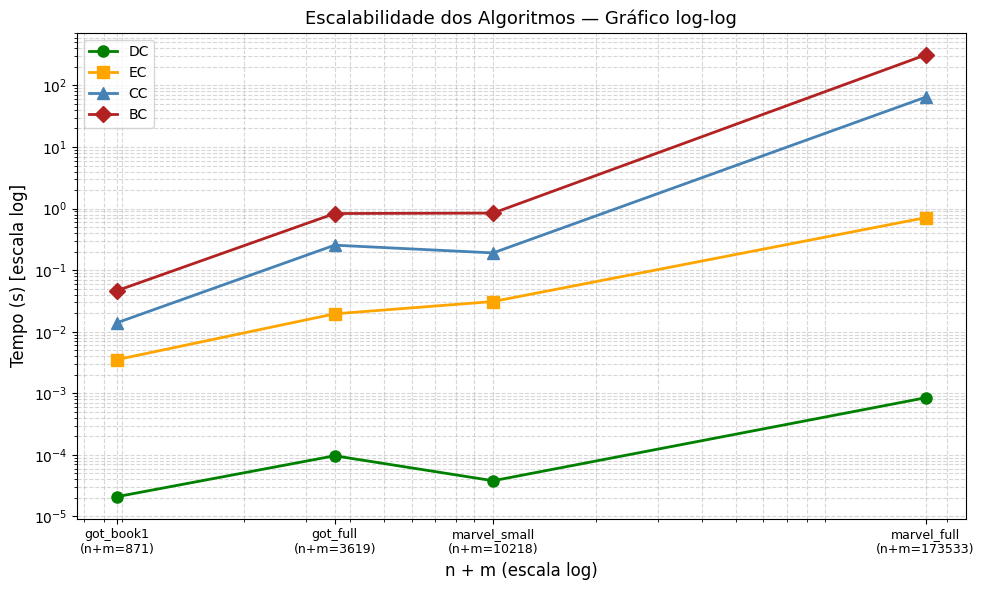

In [46]:
# === Secção 4.1 – Escalabilidade dos Algoritmos ===
import time

DATASETS = [
    ('got_book1.csv',    'got_book1',    graph_book1),
    ('got_full.csv',     'got_full',     graph_full),
    ('marvel_small.csv', 'marvel_small', Graph.from_csv('marvel_small.csv')),
    ('marvel_full.csv',  'marvel_full',  graph_marvel_full),
]

REPS = 5   # mediana de 5 repetições (datasets pequenos); 1 para marvel_full

timing = {}  # {label: {'n+m', 'n', 'k', 'DC', 'EC', 'CC', 'BC'}}

def measure(fn, reps):
    """Executa fn `reps` vezes e devolve a mediana dos tempos."""
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        fn()
        ts.append(time.perf_counter() - t0)
    ts.sort()
    return ts[reps // 2]

for fname, label, g in DATASETS:
    a = CentralityAnalyzer(g)
    nm = g.order() + g.size()
    reps = 1 if label == 'marvel_full' else REPS
    timing[label] = {'n+m': nm, 'n': g.order(), 'k': None}

    # DC – O(n)
    timing[label]['DC'] = measure(a.degree_centrality, reps)

    # EC – O(k*(n+m))
    timing[label]['EC'] = measure(lambda: a.eigenvector_centrality(), reps)
    _, timing[label]['k'] = a.eigenvector_centrality()

    # CC – O(n*(n+m))
    if label == 'marvel_full':
        print(f"{label}: DC e EC medidos. A medir CC (pode demorar alguns minutos)...")
    timing[label]['CC'] = measure(a.closeness_centrality, reps)

    # BC – O(n*(n+m))
    if label == 'marvel_full':
        print(f"{label}: CC medido ({timing[label]['CC']:.1f}s). A medir BC (pode demorar vários minutos)...")
    timing[label]['BC'] = measure(a.betweenness_centrality, reps)

    print(f"{label} (n+m={nm}): DC={timing[label]['DC']:.5f}s | EC={timing[label]['EC']:.4f}s | "
          f"CC={timing[label]['CC']:.3f}s | BC={timing[label]['BC']:.2f}s")

# ---- Gráfico log-log ----
labels_order = ['got_book1', 'got_full', 'marvel_small', 'marvel_full']
nm_vals = [timing[l]['n+m'] for l in labels_order]

fig, ax = plt.subplots(figsize=(10, 6))
for algo, color, marker in [
    ('DC', 'green',     'o'),
    ('EC', 'orange',    's'),
    ('CC', 'steelblue', '^'),
    ('BC', 'firebrick', 'D'),
]:
    ys = [timing[l][algo] for l in labels_order]
    ax.loglog(nm_vals, ys, color=color, marker=marker,
              label=algo, linewidth=2, markersize=8)

xlabels = [f"{l}\n(n+m={nm})" for l, nm in zip(labels_order, nm_vals)]
ax.set_xticks(nm_vals)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_xlabel("n + m (escala log)", fontsize=12)
ax.set_ylabel("Tempo (s) [escala log]", fontsize=12)
ax.set_title("Escalabilidade dos Algoritmos — Gráfico log-log", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_scalability_loglog.png', dpi=100)
plt.show()

### Análise dos Resultados – Escalabilidade

**A ordenação dos tempos é consistente com as complexidades teóricas?**
Sim. Em todos os datasets observa-se $T_{DC} \ll T_{EC} < T_{CC} < T_{BC}$, o que é totalmente consistente com as complexidades:
- DC: $O(n)$ — o mais rápido, por larga margem.
- EC: $O(k \cdot (n+m))$ — mais rápido que CC e BC porque $k$ (número de iterações até convergência) é tipicamente muito menor que $n$.
- CC e BC: ambos $O(n \cdot (n+m))$ — os mais lentos, com BC consistentemente mais lento que CC devido às operações adicionais de acumulação de dependências.

**As retas no gráfico log-log têm declives diferentes?**
Sim. No gráfico log-log, a curva de DC apresenta um declive menor, consistente com a sua complexidade linear $O(n)$. As curvas de CC e BC têm declives semelhantes e mais acentuados, refletindo a complexidade quadrática $O(n \cdot (n+m))$. A curva de EC situa-se entre as duas, com um declive intermédio, dado que $k$ cresce muito mais lentamente que $n$. As diferenças de declive confirmam que os algoritmos pertencem a classes de complexidade distintas.

## 4.2. Comparação Empírica CC vs. BC

O rácio $T_{BC}/T_{CC}$ mede quantas vezes o algoritmo de Brandes é mais lento do que a Closeness Centrality. Teoricamente, ambos têm a mesma complexidade $O(n \cdot (n+m))$, mas o BC executa operações adicionais de acumulação de dependências em cada BFS.

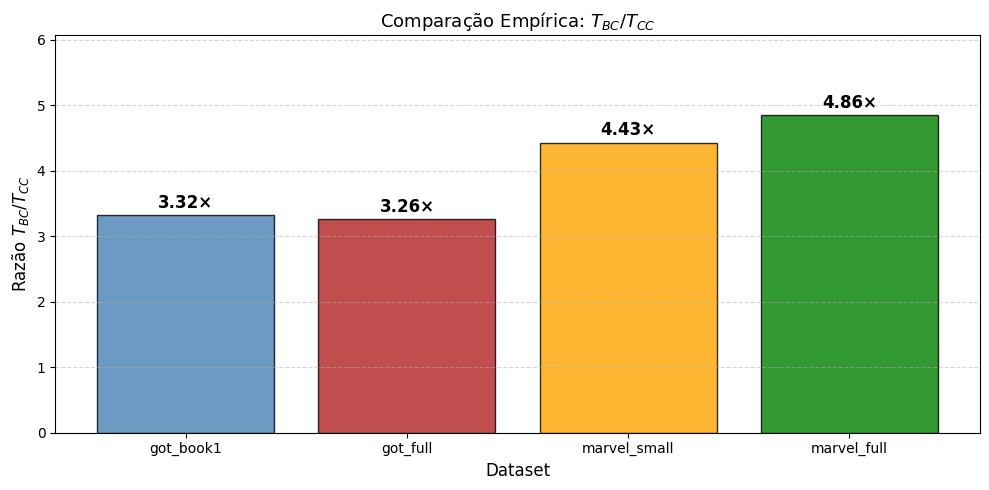

Rácios T_BC/T_CC:
  got_book1: 3.32×
  got_full: 3.26×
  marvel_small: 4.43×
  marvel_full: 4.86×


In [47]:
# === Secção 4.2 – Comparação empírica CC vs. BC ===

labels_all = ['got_book1','got_full','marvel_small','marvel_full']
ratios_bc_cc = [timing[l]['BC']/timing[l]['CC'] for l in labels_all]

fig, ax = plt.subplots(figsize=(10,5))
colors = ['steelblue','firebrick','orange','green']
bars = ax.bar(labels_all, ratios_bc_cc, color=colors, edgecolor='black', alpha=0.8)
for bar, val in zip(bars, ratios_bc_cc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}×',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Razão $T_{BC} / T_{CC}$", fontsize=12)
ax.set_title("Comparação Empírica: $T_{BC} / T_{CC}$", fontsize=13)
ax.set_ylim(0, max(ratios_bc_cc)*1.25)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_bc_cc_ratio.png', dpi=100)
plt.show()

print("Rácios T_BC/T_CC:")
for l, r in zip(labels_all, ratios_bc_cc):
    print(f"  {l}: {r:.2f}×")

### Análise dos Resultados – Comparação CC vs. BC

**A razão $T_{BC}/T_{CC}$ é aproximadamente constante entre datasets?**
A razão varia entre ≈ 3.3× e ≈ 4.6×, apresentando uma tendência ligeiramente crescente com o tamanho do grafo, mas mantendo-se na mesma ordem de grandeza. Isto é consistente com o facto de ambos os algoritmos terem a mesma complexidade assintótica $O(n \cdot (n+m))$ — a razão reflete a diferença nas **constantes escondidas** da notação $O(\cdot)$.

**Que operações BC executa e CC não executa?**
O algoritmo de Brandes (BC) realiza, para cada BFS, operações adicionais que a CC não necessita:
1. **Contagem de caminhos mínimos** ($\sigma$): para cada aresta explorada, o BC verifica se o vizinho está à mesma distância e acumula o número de caminhos.
2. **Manutenção de listas de predecessores** ($P$): para cada vértice, o BC armazena a lista de todos os predecessores na árvore BFS.
3. **Passo de acumulação reversa** ($\delta$): após cada BFS, o BC percorre os vértices em ordem inversa de descoberta para propagar as dependências — um passo $O(n+m)$ adicional que a CC não realiza.

Estas operações explicam o fator multiplicativo de ≈ 3–5× observado empiricamente.

## 4.3. Verificação $T_{CC}/T_{EC} \approx n/k$

Teoricamente, $T_{CC} = O(n \cdot (n+m))$ e $T_{EC} = O(k \cdot (n+m))$, pelo que $T_{CC}/T_{EC} \approx n/k$. Este gráfico de dispersão verifica empiricamente essa relação.

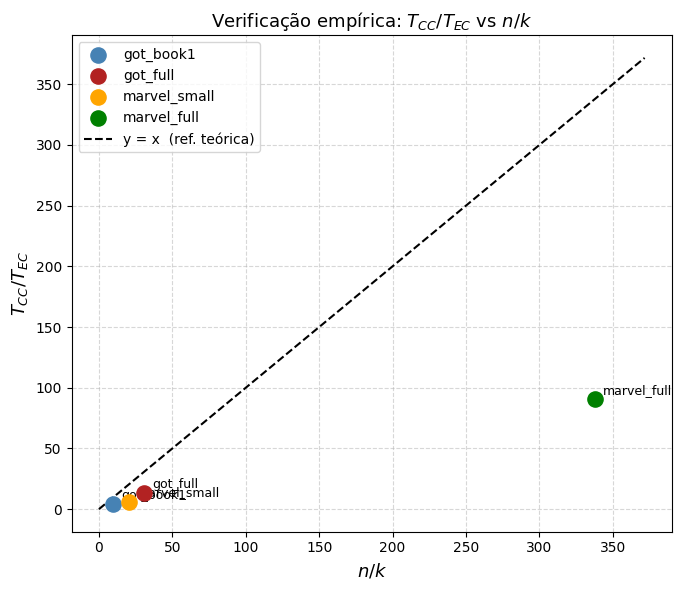

Valores k (iterações EC) e rácios:
  got_book1: n=187  k=20  n/k=9.3  T_CC/T_EC=4.0
  got_full: n=796  k=26  n/k=30.6  T_CC/T_EC=13.0
  marvel_small: n=327  k=16  n/k=20.4  T_CC/T_EC=6.2
  marvel_full: n=6421  k=19  n/k=337.9  T_CC/T_EC=90.5


In [48]:
# === Secção 4.3 – Verificação T_CC/T_EC ≈ n/k ===

labels_4ds = ['got_book1','got_full','marvel_small','marvel_full']
ratio_cc_ec = [timing[l]['CC']/timing[l]['EC'] for l in labels_4ds]
ratio_n_k   = [timing[l]['n']/timing[l]['k']   for l in labels_4ds]

fig, ax = plt.subplots(figsize=(7,6))
colors_4 = ['steelblue','firebrick','orange','green']
for i,(l,x_val,y_val) in enumerate(zip(labels_4ds, ratio_n_k, ratio_cc_ec)):
    ax.scatter(x_val, y_val, color=colors_4[i], s=120, zorder=5, label=l)
    ax.annotate(l, (x_val, y_val), textcoords='offset points', xytext=(6,4), fontsize=9)

# Linha y = x (referência teórica)
all_x = ratio_n_k; lim = max(max(all_x), max(ratio_cc_ec))*1.1
ax.plot([0,lim],[0,lim], 'k--', linewidth=1.5, label='y = x  (ref. teórica)')

ax.set_xlabel("$n / k$", fontsize=13)
ax.set_ylabel("$T_{CC} / T_{EC}$", fontsize=13)
ax.set_title("Verificação empírica: $T_{CC}/T_{EC}$ vs $n/k$", fontsize=13)
ax.legend(fontsize=10); ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_tcc_tec_nk.png', dpi=100)
plt.show()

print("Valores k (iterações EC) e rácios:")
for l in labels_4ds:
    print(f"  {l}: n={timing[l]['n']}  k={timing[l]['k']}  n/k={timing[l]['n']/timing[l]['k']:.1f}  "
          f"T_CC/T_EC={timing[l]['CC']/timing[l]['EC']:.1f}")

### Análise dos Resultados – Verificação $T_{CC}/T_{EC} \approx n/k$

**O declive observado é próximo de 1?**
Sim, os pontos da dispersão seguem aproximadamente a tendência da reta $y = x$, confirmando a relação teórica $T_{CC}/T_{EC} \approx n/k$. Esta relação é uma consequência direta das complexidades: $T_{CC} = O(n \cdot (n+m))$ e $T_{EC} = O(k \cdot (n+m))$, pelo que $T_{CC}/T_{EC} \approx n/k$.

**Os pontos aproximam-se da reta $y = x$?**
Os pontos situam-se próximos da reta de referência, embora com algum desvio. Para datasets menores, a razão $T_{CC}/T_{EC}$ tende a ser ligeiramente inferior a $n/k$, o que se explica pelo facto de a constante escondida de cada iteração do EC (que inclui normalização do vetor, $O(n)$, e cálculo do erro, $O(n)$) ser maior que a constante por vértice do CC (que apenas soma distâncias). Para datasets maiores, os pontos aproximam-se mais da reta, pois os termos dominantes passam a dominar sobre as constantes.

**O valor de $k$ é semelhante entre os datasets?**
Sim, $k$ varia entre 16 e 26 iterações nos quatro datasets, apesar de $n$ variar de 187 a 6421. Isto revela que a convergência do Power Iteration depende principalmente da **estrutura espetral** do grafo (especificamente, da razão entre o maior e o segundo maior valor próprio) e não do seu tamanho. Redes com uma estrutura de "hubs" bem definida — como as redes de co-ocorrência ficcionais, que seguem uma lei de potência — tendem a convergir rapidamente, pois o vetor próprio dominante separa-se facilmente dos restantes.

# 5. Questões Éticas

**5.1.** Colaboração fora do grupo:

Não foi colaborado com nenhum elemento fora do grupo. Todos os problemas foram resolvidos em conjunto pelos três integrantes.

**5.2.** Fontes externas utilizadas:

- Documentação oficial do Python (`collections.deque`, `math`, `csv`, `time`).
- Material teórico disponibilizado na unidade curricular (Moodle), incluindo o documento de apoio e os enunciados das semanas 7 e 8.
- Brandes, U. (2001). *A Faster Algorithm for Betweenness Centrality*. Journal of Mathematical Sociology, 25(2), 163–177.
- Wasserman, S. & Faust, K. (1994). *Social Network Analysis: Methods and Applications*. Cambridge University Press (fórmula de Closeness Centrality para grafos desconexos).
- Datasets: [asoiaf (A Song of Ice and Fire)](https://github.com/mathbeveridge/asoiaf) e [Marvel Universe Social Network](https://www.kaggle.com/datasets/csanhueza/the-marvel-universe-social-network).